In [2]:
import tensorflow as tf

print("Версия TensorFlow:", tf.__version__)
print("Доступные GPU:", tf.config.list_physical_devices('GPU'))
print("Устройство для вычислений:", tf.test.is_gpu_available())

Версия TensorFlow: 2.14.0
Доступные GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Устройство для вычислений: True


2026-04-01 20:58:01.781143: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-01 20:58:01.782515: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-01 20:58:01.783671: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [52]:
import kagglehub

# Download latest version
# path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")

path = '/home/nikita/.cache/kagglehub/datasets/mczielinski/bitcoin-historical-data/versions/555'

print("Path to dataset files:", path)

Path to dataset files: /home/nikita/.cache/kagglehub/datasets/mczielinski/bitcoin-historical-data/versions/555


In [53]:
import os
import pandas as pd
import numpy as np

file = os.listdir(path)
df_pre = pd.read_csv(path +'/' +file[0])
df_pre

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
1,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
2,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
3,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
4,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
...,...,...,...,...,...,...
7492000,1.775002e+09,68109.00,68109.00,68057.00,68098.00,0.821987
7492001,1.775002e+09,68099.00,68117.00,68081.00,68117.00,0.938345
7492002,1.775002e+09,68127.00,68167.00,68127.00,68129.00,0.459205
7492003,1.775002e+09,68129.00,68140.00,68120.00,68120.00,0.343214


In [6]:
import datetime

df = df_pre

df['date'] = pd.to_datetime(df['Timestamp'], unit='s')

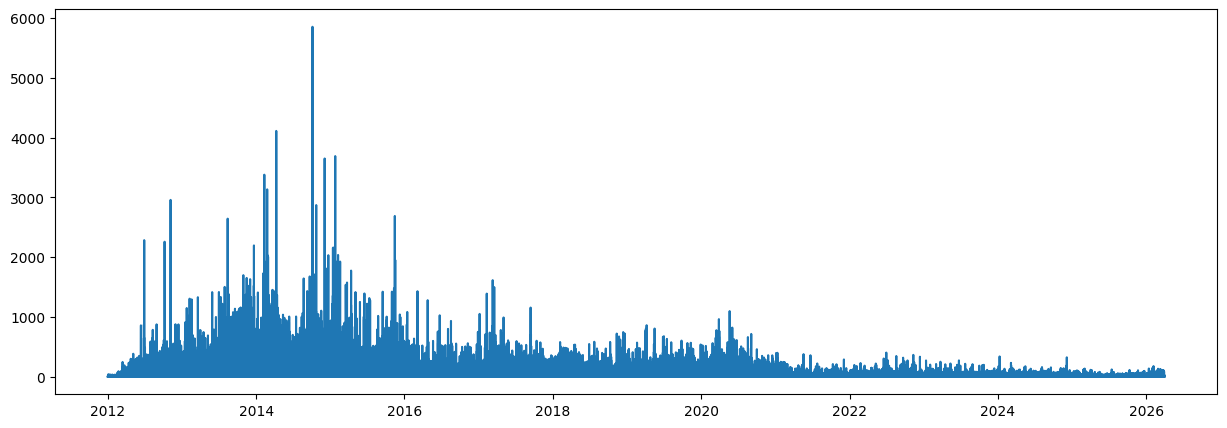

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['Volume'])
plt.show()

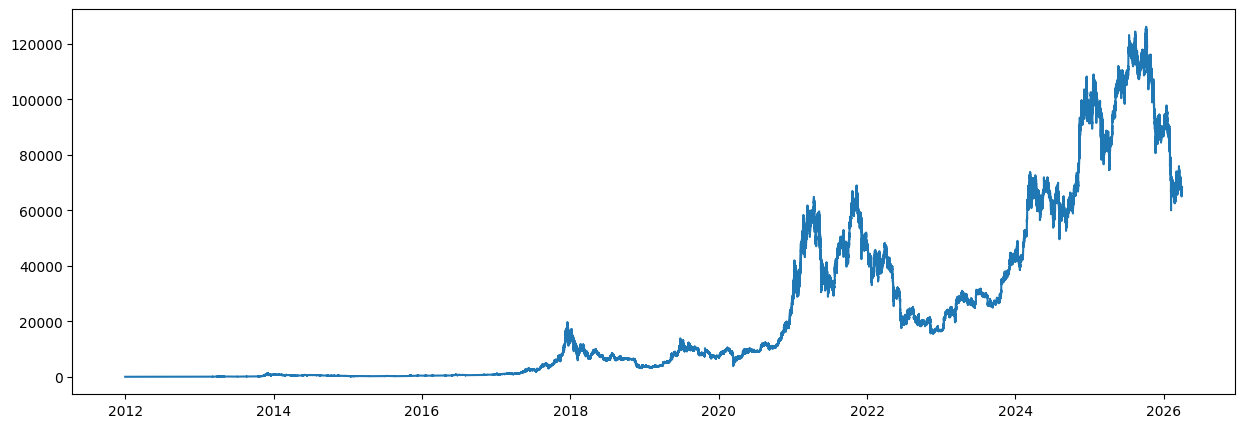

In [8]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['Close'])
plt.show()

In [9]:
df = df[df['date'] < '2025-06-01 00:00:00']
df = df.reset_index(drop=True)

df['Close'] = df['Close']
df['Volume'] = df['Volume']

df['year'] = df['date'].dt.year.astype(int)
df['month'] = df['date'].dt.month.astype(int)
df['day'] = df['date'].dt.day.astype(int)

df

,Timestamp,Open,High,Low,Close,Volume,date,year,month,day
0,1.325412e+09,4.58,4.58,4.58,4.58,0.000000,2012-01-01 10:01:00,2012,1,1
1,1.325412e+09,4.58,4.58,4.58,4.58,0.000000,2012-01-01 10:02:00,2012,1,1
2,1.325412e+09,4.58,4.58,4.58,4.58,0.000000,2012-01-01 10:03:00,2012,1,1
3,1.325412e+09,4.58,4.58,4.58,4.58,0.000000,2012-01-01 10:04:00,2012,1,1
4,1.325412e+09,4.58,4.58,4.58,4.58,0.000000,2012-01-01 10:05:00,2012,1,1
...,...,...,...,...,...,...,...,...,...,...
7054234,1.748736e+09,104663.00,104669.00,104663.00,104667.00,0.010537,2025-05-31 23:55:00,2025,5,31
7054235,1.748736e+09,104667.00,104677.00,104665.00,104665.00,0.291656,2025-05-31 23:56:00,2025,5,31
7054236,1.748736e+09,104655.00,104655.00,104655.00,104655.00,0.003500,2025-05-31 23:57:00,2025,5,31
7054237,1.748736e+09,104650.00,104651.00,104647.00,104649.00,0.496881,2025-05-31 23:58:00,2025,5,31


In [10]:
df = df.set_index('date').sort_index()
df_daily = df.resample('D').mean().dropna()
print(f"Кол-во строк {df_daily.shape[0]}")
df = df_daily
df

Кол-во строк 4900


,Timestamp,Open,High,Low,Close,Volume,year,month,day
date,,,,,,,,,
2012-01-01,1.325437e+09,4.645697,4.645697,4.645697,4.645697,0.011919,2012.0,1.0,1.0
2012-01-02,1.325506e+09,4.975000,4.975000,4.975000,4.975000,0.007014,2012.0,1.0,2.0
2012-01-03,1.325592e+09,5.085500,5.085500,5.085500,5.085500,0.074365,2012.0,1.0,3.0
2012-01-04,1.325678e+09,5.170250,5.170396,5.170250,5.170396,0.074468,2012.0,1.0,4.0
2012-01-05,1.325765e+09,5.954292,5.954361,5.954292,5.954361,0.048839,2012.0,1.0,5.0
...,...,...,...,...,...,...,...,...,...
2025-05-27,1.748347e+09,109477.372222,109502.786806,109452.650000,109477.765278,0.900425,2025.0,5.0,27.0
2025-05-28,1.748434e+09,108308.095833,108327.028472,108287.797917,108307.879861,0.749880,2025.0,5.0,28.0
2025-05-29,1.748520e+09,107472.459722,107495.506250,107448.515972,107471.598611,0.994291,2025.0,5.0,29.0


In [11]:
df = df.drop(['Timestamp', 'Open', 'High', 'Low'], axis = 1)

df

,Close,Volume,year,month,day
date,,,,,
2012-01-01,4.645697,0.011919,2012.0,1.0,1.0
2012-01-02,4.975000,0.007014,2012.0,1.0,2.0
2012-01-03,5.085500,0.074365,2012.0,1.0,3.0
2012-01-04,5.170396,0.074468,2012.0,1.0,4.0
2012-01-05,5.954361,0.048839,2012.0,1.0,5.0
...,...,...,...,...,...
2025-05-27,109477.765278,0.900425,2025.0,5.0,27.0
2025-05-28,108307.879861,0.749880,2025.0,5.0,28.0
2025-05-29,107471.598611,0.994291,2025.0,5.0,29.0


In [15]:
len_split = 30

df['lag_close_1'] = df['Close'].shift(1).fillna(0)
for i in range(2, len_split):
    df[f'lag_close_{i}'] = df[f'lag_close_{i-1}'].shift(1).fillna(0)

df['lag_volume_1'] = df['Volume'].shift(1).fillna(0)
for i in range(2, len_split):
    df[f'lag_volume_{i}'] = df[f'lag_volume_{i-1}'].shift(1).fillna(0)

df

,Close,Volume,year,month,day,lag_close_1,lag_close_2,lag_close_3,lag_close_4,lag_close_5,...,lag_volume_20,lag_volume_21,lag_volume_22,lag_volume_23,lag_volume_24,lag_volume_25,lag_volume_26,lag_volume_27,lag_volume_28,lag_volume_29
date,,,,,,,,,,,,,,,,,,,,,
2012-01-01,4.645697,0.011919,2012.0,1.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2012-01-02,4.975000,0.007014,2012.0,1.0,2.0,4.645697,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2012-01-03,5.085500,0.074365,2012.0,1.0,3.0,4.975000,4.645697,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2012-01-04,5.170396,0.074468,2012.0,1.0,4.0,5.085500,4.975000,4.645697,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2012-01-05,5.954361,0.048839,2012.0,1.0,5.0,5.170396,5.085500,4.975000,4.645697,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-27,109477.765278,0.900425,2025.0,5.0,27.0,109590.865278,107669.667361,108493.759722,109902.488889,111007.937500,...,0.925884,0.746274,0.650648,0.390815,0.483593,0.638339,1.209852,0.961280,0.609496,1.091277
2025-05-28,108307.879861,0.749880,2025.0,5.0,28.0,109477.765278,109590.865278,107669.667361,108493.759722,109902.488889,...,1.599627,0.925884,0.746274,0.650648,0.390815,0.483593,0.638339,1.209852,0.961280,0.609496
2025-05-29,107471.598611,0.994291,2025.0,5.0,29.0,108307.879861,109477.765278,109590.865278,107669.667361,108493.759722,...,0.927837,1.599627,0.925884,0.746274,0.650648,0.390815,0.483593,0.638339,1.209852,0.961280


In [62]:
X = df.drop(['Close'], axis = 1)
y = df[['Close']]

X = X.to_numpy()
y = y.to_numpy()

X = X[len_split:]
y = y[len_split:]

In [64]:
from sklearn.preprocessing import MinMaxScaler

x_scaler = MinMaxScaler(feature_range=(0, 1))
y_scaler = MinMaxScaler(feature_range=(0, 1))
x_resh_scaler = MinMaxScaler(feature_range=(0, 1))

X_scaled = x_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y)

X_resh_scaled = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

In [76]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.0063, shuffle=False)
x_resh_train, x_resh_test, _, _ = train_test_split(X_resh_scaled, y_scaled, test_size=0.0063, shuffle=False)

In [77]:
x_scaler.inverse_transform(x_test)[0][1:4] #1 мая 2025

array([2.025e+03, 5.000e+00, 1.000e+00])

In [78]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_resh_train = x_resh_train.astype('float32')
x_resh_test = x_resh_test.astype('float32')
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

In [79]:
x_resh_train.shape

(4839, 62, 1)

In [87]:
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import EarlyStopping

model = keras.Sequential([
    keras.layers.GRU(32, return_sequences=False, activation='tanh', input_shape=(x_resh_train.shape[1], x_resh_train.shape[2])),
    # keras.layers.GRU(32, return_sequences=False, activation='tanh'),
    keras.layers.Dense(1)
])

# model.summary()


model.compile(  optimizer = keras.optimizers.Adam(learning_rate = 1e-5),#3e-4
                loss = 'mse',
                metrics = ['R2Score']
                )

early_stopping = EarlyStopping(
                    monitor='val_r2_score',
                    patience = 25,
                    min_delta = 0.001,
                    verbose = 0,
                    restore_best_weights = True,
                    mode = 'max'
                    )

model.fit(
        x = x_resh_train,
        y = y_train,
        batch_size = 1,
        epochs = 2000,
        verbose = 1,
        callbacks = [early_stopping], 
        shuffle = False,
        validation_split=0,
        validation_data = (x_test, y_test),
        validation_batch_size = 1
        )

train_loss, keras_train_r2 = model.evaluate(x_train, y_train)
test_loss, keras_test_r2 = model.evaluate(x_test, y_test)
print('\nдля нейронной сети R^2 метрика для обучающей \ тестовой выборки:', keras_train_r2, ' \ ', keras_test_r2)

Epoch 1/2000
4839/4839 [==============================] - 18s 4ms/step - loss: 0.0120 - r2_score: 0.7449 - val_loss: 0.1246 - val_r2_score: -65.9048
Epoch 2/2000
4839/4839 [==============================] - 16s 3ms/step - loss: 0.0505 - r2_score: -0.0738 - val_loss: 0.1501 - val_r2_score: -79.6112
Epoch 3/2000
4839/4839 [==============================] - 16s 3ms/step - loss: 0.0403 - r2_score: 0.1434 - val_loss: 0.0945 - val_r2_score: -49.7639
Epoch 4/2000
4839/4839 [==============================] - 16s 3ms/step - loss: 0.0387 - r2_score: 0.1776 - val_loss: 0.0582 - val_r2_score: -30.2726
Epoch 5/2000
4839/4839 [==============================] - 17s 3ms/step - loss: 0.0363 - r2_score: 0.2289 - val_loss: 0.0357 - val_r2_score: -18.1954
Epoch 6/2000
4839/4839 [==============================] - 17s 3ms/step - loss: 0.0339 - r2_score: 0.2792 - val_loss: 0.0258 - val_r2_score: -12.8307
Epoch 7/2000
4839/4839 [==============================] - 17s 3ms/step - loss: 0.0317 - r2_score: 0.3273 

1/1 [==============================] - 0s 13ms/step
predict : [0.8354471] 	true [0.8637025] 	diff, % [3.3820748]
predict : [0.83973646] 	true [0.87385535] 	diff, % [4.063046]
predict : [0.84428734] 	true [0.8677799] 	diff, % [2.7825356]
predict : [0.8486036] 	true [0.86124647] 	diff, % [1.4898419]
predict : [0.85257304] 	true [0.85030633] 	diff, % [-0.26586652]
predict : [0.85710025] 	true [0.8516267] 	diff, % [-0.6386101]
predict : [0.86307514] 	true [0.8723311] 	diff, % [1.0724425]
predict : [0.86942077] 	true [0.901348] 	diff, % [3.6722422]
predict : [0.87709695] 	true [0.9278786] 	diff, % [5.789745]
predict : [0.8840212] 	true [0.9319823] 	diff, % [5.425334]
predict : [0.8907088] 	true [0.9384902] 	diff, % [5.36443]
predict : [0.89738077] 	true [0.9329777] 	diff, % [3.9667606]
predict : [0.9043733] 	true [0.9310688] 	diff, % [2.9518247]
predict : [0.9111396] 	true [0.9333888] 	diff, % [2.441907]
predict : [0.9178716] 	true [0.9264576] 	diff, % [0.9354234]
predict : [0.9247199] 	tru

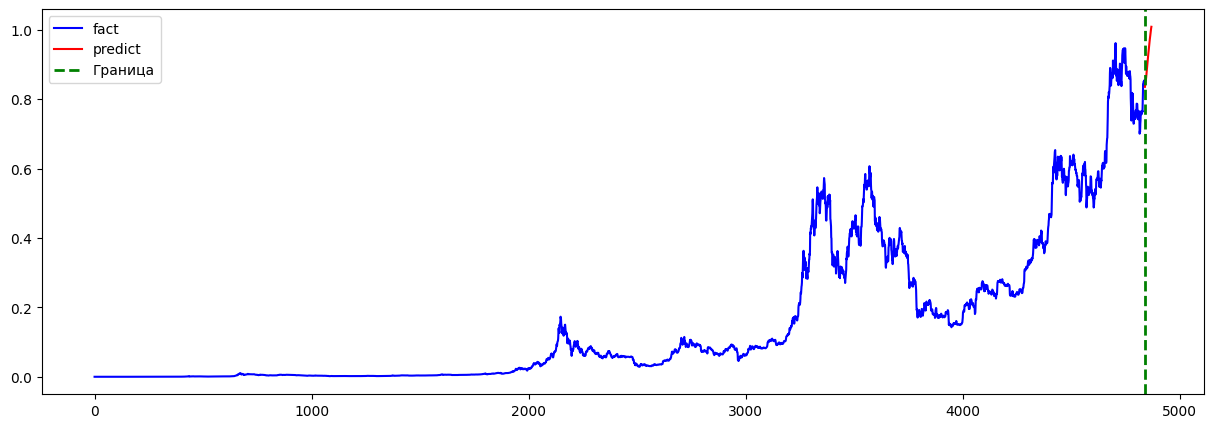

In [109]:
def model_predict(model, x_train, y_train, x_test, y_test):

    try:
        train_loss, keras_train_r2 = model.evaluate(x_train, y_train)
        test_loss, keras_test_r2 = model.evaluate(x_test, y_test)
    except AttributeError:
        keras_train_r2 = model.score(x_train, y_train)
        keras_test_r2 = model.score(x_test, y_test)

    fact = y_train
    predict = model.predict(x_test)

    for i in range(len(y_test)):
        print('predict :', predict[i],'\ttrue', y_test[i], '\tdiff, %', (y_test[i]/predict[i] - 1)*100)

    print('----------------')
    print('min \ max diff:', min( [(y_test[i]/predict[i] - 1)*100 for i in range(len(y_test))] ), ' \ ', max( [(y_test[i]/predict[i] - 1)*100 for i in range(len(y_test))] ))
    print('----------------')
    print('R^2 метрика для обучающей \ тестовой выборки:', keras_train_r2, ' \ ', keras_test_r2)
    print('----------------')
    
    plt.figure(figsize=(15, 5))
    plt.plot(range(len(fact)), fact, color='blue', label='fact')
    plt.plot(range(len(fact), len(fact) + len(predict)), predict, color='red', label='predict')
    plt.axvline(x=len(fact) - 1, color='green', linestyle='--', linewidth=2, label='Граница')
    plt.legend()
    plt.show()

model_predict(model, x_train, y_train, x_test, y_test)

predict : [0.8489547] 	true [0.8637025] 	diff, % [1.7371774]
predict : [0.86760247] 	true [0.87385535] 	diff, % [0.7207036]
predict : [0.876101] 	true [0.8677799] 	diff, % [-0.9497881]
predict : [0.8671268] 	true [0.86124647] 	diff, % [-0.6781399]
predict : [0.86264783] 	true [0.85030633] 	diff, % [-1.4306545]
predict : [0.85025805] 	true [0.8516267] 	diff, % [0.1609683]
predict : [0.851597] 	true [0.8723311] 	diff, % [2.4347305]
predict : [0.87675804] 	true [0.901348] 	diff, % [2.8046489]
predict : [0.90660626] 	true [0.9278786] 	diff, % [2.3463726]
predict : [0.93082106] 	true [0.9319823] 	diff, % [0.12475252]
predict : [0.9323145] 	true [0.9384902] 	diff, % [0.66241026]
predict : [0.93964195] 	true [0.9329777] 	diff, % [-0.70923567]
predict : [0.93333936] 	true [0.9310688] 	diff, % [-0.24327636]
predict : [0.92913055] 	true [0.9333888] 	diff, % [0.45831203]
predict : [0.93404764] 	true [0.9264576] 	diff, % [-0.8125961]
predict : [0.92499113] 	true [0.93555814] 	diff, % [1.1423945]
p

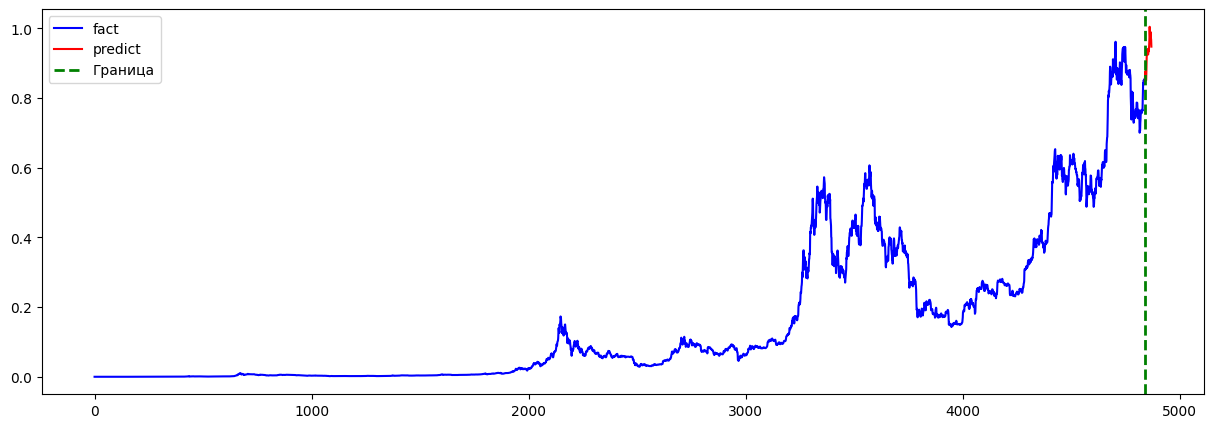

In [110]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_percentage_error

model_reg = LinearRegression()
model_reg.fit(x_train, y_train)

model_predict(model_reg, x_train, y_train, x_test, y_test)

In [111]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from pmdarima.arima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
import sklearn.metrics as metric
from statsmodels.tsa.stattools import acf
from scipy.stats import pearsonr
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [116]:
def train_predict_arima(predicted_data, model, predicted_data_2 = None, test_size = 0.1):
    series = df[predicted_data]
    train_size = int(len(series) * (1-test_size))
    train, test = series[:train_size], series[train_size:]

    print('Model is', model)
    
    if model == 'arima':
        seas = 0
        auto_ar = auto_arima(series, seasonal=False, trace=False)
        arima_model = ARIMA(train, order=auto_ar.order)
        arima_model = arima_model.fit()
    
    elif model == 'sarimax':
        seas = 5
        auto_ar = auto_arima(series, seasonal=True, m=seas, 
            trace=False, stepwise=True, # Faster optimization
            suppress_warnings=True, error_action="ignore")
        arima_model = SARIMAX(train, order=auto_ar.order, # Non-seasonal (p,d,q)
            seasonal_order=auto_ar.order+(seas,),      # Seasonal (P,D,Q,S)
            enforce_stationarity=False)
        arima_model = arima_model.fit()
    
    elif model == 'varima':

        cols = [predicted_data, predicted_data_2]
        data_multi = df[cols]

        train_size_multi = int(len(data_multi) * (1-test_size))
        train_multi, test_multi = data_multi.iloc[:train_size_multi], data_multi.iloc[train_size_multi:]
        
        # Подбор порядка VAR по AIC (макс. лагов 10)
        var_model = VAR(train_multi)
        var_order = var_model.select_order(maxlags=10)
        p = var_order.aic
        if p is None or p == 0:
            p = 1
        print(f"Selected VAR order: {p}")
        
        var_fitted = var_model.fit(p)
        
        fitted_multi = var_fitted.fittedvalues
        predicted_full = pd.Series(index=train_multi.index, dtype=float)
        predicted_full.iloc[p:] = fitted_multi[predicted_data].values
        predicted = predicted_full
        
        last_obs = train_multi.iloc[-p:].values
        forecasts_list = []
        for i in range(len(test_multi)):
            next_forecast = var_fitted.forecast(y=last_obs, steps=1)
            forecasts_list.append(next_forecast[0])
            actual = test_multi.iloc[i].values
            last_obs = np.vstack([last_obs[1:], actual])
        forecasts_multi = np.array(forecasts_list)
        target_index = cols.index(predicted_data)
        forecasts = pd.Series(forecasts_multi[:, target_index], index=test_multi.index)
        
        arima_model = var_fitted
        seas = p  
        
    else:
        return None

    if model in ['arima', 'sarimax']:
        predicted = arima_model.predict(start=1, end=len(train))

        results = arima_model
        forecasts = [results.forecast(steps=1).iloc[0]] 
    
        for i in range(len(test)):
            results = results.append(test.iloc[i:i+1], refit=False)
    
            forecasts.append(results.forecast(steps=1).iloc[0])

        forecasts = forecasts[:-1] 

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(train.index[seas:], train[seas:], label='Train')
    ax1.plot(train.index[seas:], predicted[seas:], label='Predict', linestyle='--')
    ax1.set_title(f'Train vs Predict (r2_score = {round(metric.r2_score(predicted[seas:], train[seas:]), 4)})')
    ax1.legend()

    ax2.plot(test.index[seas:], test[seas:], label="Test")
    ax2.plot(test.index[seas:], forecasts[seas:], label="Forecast", linestyle="--")
    ax2.set_title(f'Test vs Forecast (r2_score = {round(metric.r2_score(forecasts[seas:], test[seas:]), 4)})')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # results.plot_diagnostics(figsize=(8,8))
    # plt.show()


Model is arima


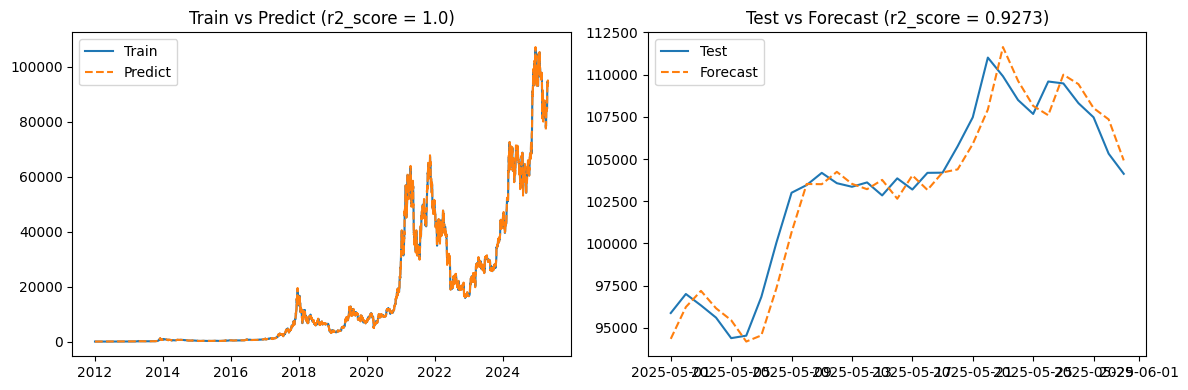

Model is sarimax


/home/nikita/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


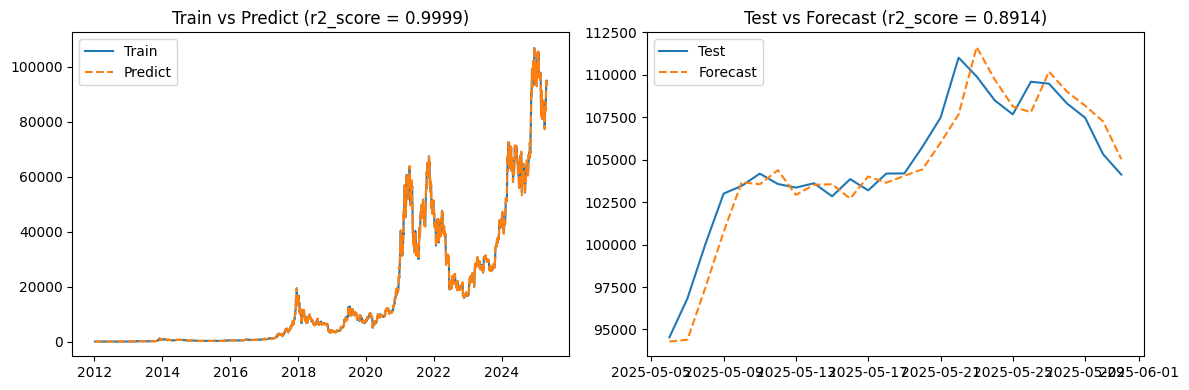

In [117]:
arr_arima = ['arima', 'sarimax']

for arrim in arr_arima:
    train_predict_arima('Close', arrim, None, 0.0063)